rqmts

In [ ]:
!pip install selenium pandas numpy tldextract scapy requests pyod scikit-learn -q selenium-wire matplotlib joblib

!apt-get update && apt-get install -y chromium-chromedriver

!pip install beautifulsoup4 joblib



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.7/169.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.6/239.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 492.9/492.9 kB 7.4 MB/s eta 0:00:00
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 http://security.u

libr

In [ ]:
import pandas as pd
import numpy as np
import joblib
import requests
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
import urllib.parse
from collections import Counter
from math import log2
import re
import tldextract
import random
from scapy.all import sniff, IP, TCP
from pyod.models.knn import KNN
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from bs4 import BeautifulSoup
import socket





upload csv url

In [ ]:
from google.colab import files, drive
# uploaded = files.upload()  # Upload a list_urls csv file with a 'url' column
# df = pd.read_csv(next(iter(uploaded)))
df= pd.read_csv('/content/list_urls_label.csv')
# display(df.head())

df conv

In [ ]:
if 'url' not in df.columns:
    raise ValueError("Your dataset must have a 'url' column")

display(df.head())
urls = df['url'].dropna().tolist()
print("Loaded URLs:", len(urls))


,url,phish_id,phish_detail_url,submission_time,verified,verification_time,online,target,having_IP_Address,URL_Length,...,entropy_file,entropy_ext,entropy_after_path,URL_sensitiveWord,URLQueries_variable,spcharUrl,delimeter_Domain,delimeter_path,delimeter_Count,label
0,http://000webhostvk.000webhostapp.com/,6543274.0,http://www.phishtank.com/phish_detail.php?phis...,2020-05-02T17:03:06+00:00,yes,2020-05-02T17:04:36+00:00,yes,Other,0,38,...,0.0,0.0,0.000000,0,0,6,2,1,5,0
1,http://00324il.moonfruit.com,6444671.0,http://www.phishtank.com/phish_detail.php?phis...,2020-03-11T14:37:39+00:00,yes,2020-03-11T14:47:28+00:00,yes,Other,0,28,...,0.0,0.0,0.000000,0,0,5,2,0,4,0
2,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,6447332.0,http://www.phishtank.com/phish_detail.php?phis...,2020-03-12T21:05:09+00:00,yes,2020-04-05T10:12:55+00:00,yes,Other,0,63,...,0.0,0.0,0.000000,0,0,7,2,2,6,0
3,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,6107536.0,http://www.phishtank.com/phish_detail.php?phis...,2019-07-04T18:56:39+00:00,yes,2019-07-26T11:23:08+00:00,yes,Other,0,84,...,0.0,0.0,3.921928,0,1,10,2,2,7,1
4,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,6136546.0,http://www.phishtank.com/phish_detail.php?phis...,2019-07-26T16:53:52+00:00,yes,2019-08-20T10:22:22+00:00,yes,Other,0,81,...,0.0,0.0,3.616875,0,1,9,2,2,7,1


Loaded URLs: 50236


ft extr

network traff

In [ ]:
def analyze_network_traffic(url):
    try:
        response = requests.get(url, timeout=5)
        content_length = len(response.content)
        status_code = response.status_code
        return content_length, status_code
    except requests.exceptions.RequestException as e:
        print(f"Error fetching {url}: {e}")
        return 0, 0



for all url

In [ ]:
# traffic_lengths = []
# status_codes = []
# redirections = []

# print("Analyzing URLs (this might take some time)...")
# for url in urls:
#     cl, sc, rd = analyze_network_traffic(url)
#     traffic_lengths.append(cl)
#     status_codes.append(sc)
#     redirections.append(rd)

# # Step 6: Add these to the dataframe
# df['content_length'] = traffic_lengths
# df['status_code'] = status_codes
# df['redirection'] = redirections

isol envt

In [ ]:
# Simulate isolated environment URL interaction (for Colab: just checks content length and status code)


# def open_in_isolated_environment(url):
#     try:
#         response = requests.get(url, timeout=5)
#         content_length = len(response.content)
#         status_code = response.status_code
#         if status_code == 200:
#             return 0.7 if content_length > 1000 else 0.3
#         else:
#             return 1.0
#     except Exception as e:
#         print(f"Error with {url}: {e}")
#         return 1.0



def open_in_isolated_environment(url):
    try:
        response = requests.get(url, timeout=5)
        content_length = len(response.content)
        status_code = response.status_code

        if status_code == 200:
            threat_score = 0.7 if content_length > 1000 else 0.3
        else:
            threat_score = 1.0

        print(f"[INFO] URL: {url} | Status: {status_code} | Size: {content_length} bytes | Threat: {threat_score}")
        return threat_score

    except Exception as e:
        print(f"[ERROR] URL: {url} | Exception: {e}")
        return 1.0

anomaly det model

In [ ]:
# def build_anomaly_model(feature_data):
#     # Standardize the data for better performance of anomaly detection
#     scaler = StandardScaler()
#     feature_data_scaled = scaler.fit_transform(feature_data)

#     # Build the anomaly detection model using KNN
#     model = KNN()
#     model.fit(feature_data_scaled)

#     return model, scaler

# def get_anomaly_score(model, scaler, features):
#     features_scaled = scaler.transform([features])
#     return model.decision_function(features_scaled)[0]


# Function: Anomaly detection using Isolation Forest

def train_anomaly_model(dataset):
    # Drop non-numeric columns (like 'url', 'label')
    numeric_data = dataset.drop(columns=['url', 'label'], errors='ignore')
    numeric_data = numeric_data.select_dtypes(include=[np.number])

    model = IsolationForest(contamination=0.1, random_state=42)
    model.fit(numeric_data)

    return model, numeric_data.columns.tolist()


# def detect_anomaly(feature_vector, model):
#     features_array = np.array(feature_vector).reshape(1, -1)
#     score = model.decision_function(features_array)[0]
#     return score


In [ ]:
# def process_urls(dataset):
#     threat_scores, anomaly_scores, predictions = [], [], []

#     for index, row in dataset.iterrows():
#         url = row['url']

#         # Drop unneeded columns (you can customize which features to use)
#         # Select only numeric feature columns (drop URL/label/strings)
#         feature_vector = row.drop(labels=['url', 'label'], errors='ignore')
#         numeric_features = feature_vector.select_dtypes(include=[np.number]).values

#         # Simulated analysis
#         threat_score = open_in_isolated_environment(url)
#         anomaly_score = detect_anomaly(numeric_features)


#         # Predict phishing
#         combined_score = threat_score + anomaly_score
#         prediction = 1 if combined_score > 1.0 else 0

#         # Store
#         threat_scores.append(threat_score)
#         anomaly_scores.append(anomaly_score)
#         predictions.append(prediction)

#         print(f"[{index}] URL: {url} | Threat: {threat_score:.2f} | Anomaly: {anomaly_score:.2f} → Predicted: {'Phish' if prediction else 'Safe'}")

#     # Add results to dataset
#     dataset['threat_score'] = threat_scores
#     dataset['anomaly_score'] = anomaly_scores
#     dataset['prediction'] = predictions

#     return dataset


def process_urls(dataset):
    threat_scores, anomaly_scores, predictions = [], [], []

    anomaly_model, required_feature_names = train_anomaly_model(dataset)

    for index, row in dataset.iterrows():
        url = row['url']

        # Ensure the correct numeric feature vector
        feature_vector = row[required_feature_names]
        numeric_features = np.array(feature_vector).reshape(1, -1)

        # Simulate threat analysis
        threat_score = open_in_isolated_environment(url)
        anomaly_score = anomaly_model.decision_function(numeric_features)[0]

        # Combine
        combined_score = threat_score + anomaly_score
        prediction = 1 if combined_score > 1.0 else 0

        threat_scores.append(threat_score)
        anomaly_scores.append(anomaly_score)
        predictions.append(prediction)

        print(f"[{index}] URL: {url} | Threat: {threat_score:.2f} | Anomaly: {anomaly_score:.2f} → Predicted: {'Phish' if prediction else 'Safe'}")

    # Add scores to dataframe
    dataset['threat_score'] = threat_scores
    dataset['anomaly_score'] = anomaly_scores
    dataset['prediction'] = predictions

    return dataset


In [ ]:




# Step 6: Example dataset to test the function
# data = {'URL': ['http://example.com', 'https://secure-bank-login.com', 'http://bit.ly/phish']}
# df = pd.DataFrame(data)


# Process the uploaded dataset
processed_df = process_urls(df.head(8000))

# Save to new CSV
output_file = "processed_with_score.csv"
processed_df.to_csv(output_file, index=False)

print(f"\n✅ Processing complete! File saved as '{output_file}'")



[ERROR] URL: http://000webhostvk.000webhostapp.com/ | Exception: HTTPConnectionPool(host='000webhostvk.000webhostapp.com', port=80): Max retries exceeded with url: / (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x7d9304a13210>: Failed to resolve '000webhostvk.000webhostapp.com' ([Errno -2] Name or service not known)"))
[0] URL: http://000webhostvk.000webhostapp.com/ | Threat: 1.00 | Anomaly: 0.04 → Predicted: Phish


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


[INFO] URL: http://00324il.moonfruit.com | Status: 200 | Size: 214047 bytes | Threat: 0.7
[1] URL: http://00324il.moonfruit.com | Threat: 0.70 | Anomaly: 0.00 → Predicted: Safe


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


[INFO] URL: http://03418f6.netsolhost.com/FF7AADF203DF6C7A0B7C8A74B8164E55/ | Status: 400 | Size: 226 bytes | Threat: 1.0
[2] URL: http://03418f6.netsolhost.com/FF7AADF203DF6C7A0B7C8A74B8164E55/ | Threat: 1.00 | Anomaly: -0.00 → Predicted: Safe
[INFO] URL: http://03418f6.netsolhost.com/FF7AADF203DF6C7A0B7C8A74B8164E55/?sec=Milka%20Gostovic | Status: 400 | Size: 226 bytes | Threat: 1.0


...

[INFO] URL: http://deadspin.com/senators-coach-is-issuing-threats-after-just-one-game-1698184913/1698236303/+barryap | Status: 404 | Size: 160810 bytes | Threat: 1.0
[7998] URL: http://deadspin.com/senators-coach-is-issuing-threats-after-just-one-game-1698184913/1698236303/+barryap | Threat: 1.00 | Anomaly: 0.11 → Predicted: Phish


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


[INFO] URL: http://deadspin.com/senators-coach-is-issuing-threats-after-just-one-game-1698184913/1698236303/layer/ | Status: 404 | Size: 160810 bytes | Threat: 1.0
[7999] URL: http://deadspin.com/senators-coach-is-issuing-threats-after-just-one-game-1698184913/1698236303/layer/ | Threat: 1.00 | Anomaly: 0.10 → Predicted: Phish


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
<ipython-input-10-b1c586c6dfc7>:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['threat_score'] = threat_scores
<ipython-input-10-b1c586c6dfc7>:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['anomaly_score'] = anomaly_scores
<ipython-input-10-b1c586c6dfc7>:65: SettingWithCopyWarning: 
A value is try


✅ Processing complete! File saved as 'processed_with_score.csv'


In [ ]:
disp= pd.read_csv('/content/processed_with_score.csv')
display(disp.head())

,url,phish_id,phish_detail_url,submission_time,verified,verification_time,online,target,having_IP_Address,URL_Length,...,URL_sensitiveWord,URLQueries_variable,spcharUrl,delimeter_Domain,delimeter_path,delimeter_Count,label,threat_score,anomaly_score,prediction
0,http://000webhostvk.000webhostapp.com/,6543274.0,http://www.phishtank.com/phish_detail.php?phis...,2020-05-02T17:03:06+00:00,yes,2020-05-02T17:04:36+00:00,yes,Other,0,38,...,0,0,6,2,1,5,0,1.0,0.036280,1
1,http://00324il.moonfruit.com,6444671.0,http://www.phishtank.com/phish_detail.php?phis...,2020-03-11T14:37:39+00:00,yes,2020-03-11T14:47:28+00:00,yes,Other,0,28,...,0,0,5,2,0,4,0,0.7,0.000911,0
2,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,6447332.0,http://www.phishtank.com/phish_detail.php?phis...,2020-03-12T21:05:09+00:00,yes,2020-04-05T10:12:55+00:00,yes,Other,0,63,...,0,0,7,2,2,6,0,1.0,-0.002900,0
3,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,6107536.0,http://www.phishtank.com/phish_detail.php?phis...,2019-07-04T18:56:39+00:00,yes,2019-07-26T11:23:08+00:00,yes,Other,0,84,...,0,1,10,2,2,7,1,1.0,-0.042745,0
4,http://03418f6.netsolhost.com/FF7AADF203DF6C7A...,6136546.0,http://www.phishtank.com/phish_detail.php?phis...,2019-07-26T16:53:52+00:00,yes,2019-08-20T10:22:22+00:00,yes,Other,0,81,...,0,1,9,2,2,7,1,1.0,-0.031960,0


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import confusion_matrix, accuracy_score

# # Check if label exists in your dataset
# if 'label' not in processed_df.columns:
#     print("No ground truth labels found for accuracy evaluation.")
# else:
#     # Compute overall accuracy
#     acc = accuracy_score(processed_df['label'], processed_df['prediction'])
#     print(f"\nOverall Accuracy: {acc:.4f}")

#     # 1. 📊 Scatter plot of Anomaly Score vs Threat Score
#     plt.figure(figsize=(8, 6))
#     sns.scatterplot(
#         data=processed_df,
#         x='anomaly_score',
#         y='threat_score',
#         hue='prediction',
#         style='label',
#         palette='Set1'
#     )
#     plt.title("Threat vs Anomaly Score with Predictions")
#     plt.xlabel("Anomaly Score")
#     plt.ylabel("Threat Score")
#     plt.grid(True)
#     plt.legend(title="Prediction")
#     plt.show()

#     # 2. Confusion Matrix
#     cm = confusion_matrix(processed_df['label'], processed_df['prediction'])
#     plt.figure(figsize=(6, 4))
#     sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Safe', 'Phish'], yticklabels=['Safe', 'Phish'])
#     plt.title("Confusion Matrix")
#     plt.xlabel("Predicted")
#     plt.ylabel("Actual")
#     plt.show()

#     # 3. Line plot of accuracy over thresholds
#     thresholds = np.arange(0.0, 2.0, 0.05)
#     accuracies = []

#     for t in thresholds:
#         preds = (processed_df['anomaly_score'] + processed_df['threat_score'] > t).astype(int)
#         acc = accuracy_score(processed_df['label'], preds)
#         accuracies.append(acc)

#     plt.figure(figsize=(8, 5))
#     plt.plot(thresholds, accuracies, marker='o')
#     plt.title("Accuracy over Different Thresholds (Anomaly + Threat Score)")
#     plt.xlabel("Threshold for Prediction (Anomaly + Threat)")
#     plt.ylabel("Accuracy")
#     plt.grid(True)
#     plt.show()



🎯 Accuracy: 0.5716


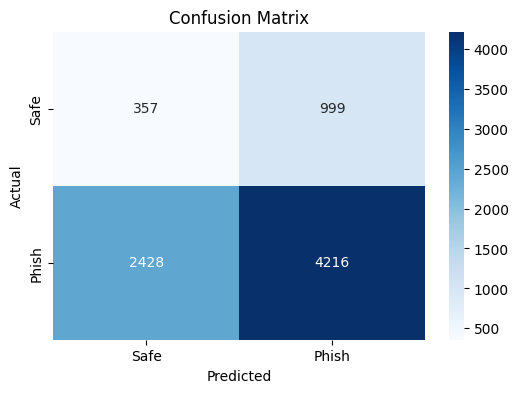

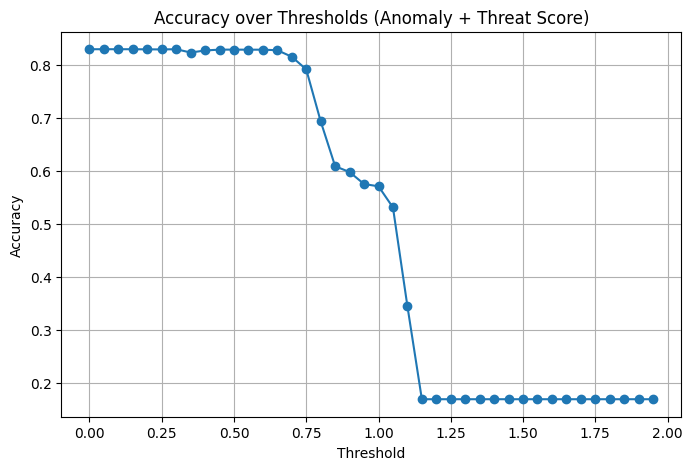

In [ ]:
required_cols = ['label', 'prediction', 'anomaly_score', 'threat_score']
for col in required_cols:
    if col not in disp.columns:
        raise ValueError(f"Missing required column: {col}")

# 🎯 Step 4: Accuracy Score
acc = accuracy_score(disp['label'], disp['prediction'])
print(f"\n🎯 Accuracy: {acc:.4f}")

# 📉 Step 5: Confusion Matrix
cm = confusion_matrix(disp['label'], disp['prediction'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Safe', 'Phish'], yticklabels=['Safe', 'Phish'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 📈 Step 6: Accuracy over Varying Thresholds (anomaly_score + threat_score)
thresholds = np.arange(0.0, 2.0, 0.05)
accuracies = []

for t in thresholds:
    preds = (disp['anomaly_score'] + disp['threat_score'] > t).astype(int)
    acc = accuracy_score(disp['label'], preds)
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, accuracies, marker='o')
plt.title("Accuracy over Thresholds (Anomaly + Threat Score)")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()